<a href="https://colab.research.google.com/github/smruthi215/DLG--LAB/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [42]:
covtype = fetch_covtype()

X = covtype.data
y = covtype.target

print("Dataset loaded successfully.")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))
print("Classes:", np.unique(y))

Dataset loaded successfully.
Number of samples: 581012
Number of features: 54
Number of classes: 7
Classes: [1 2 3 4 5 6 7]


In [43]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFirst 5 samples:")
print(X[:5])

print("\nFirst 20 target values:")
print(y[:20])

Feature matrix shape: (581012, 54)
Target shape: (581012,)

First 5 samples:
[[ 2.596e+03  5.100e+01  3.000e+00  2.580e+02  0.000e+00  5.100e+02
   2.210e+02  2.320e+02  1.480e+02  6.279e+03  1.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   1.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00]
 [ 2.590e+03  5.600e+01  2.000e+00  2.120e+02 -6.000e+00  3.900e+02
   2.200e+02  2.350e+02  1.510e+02  6.225e+03  1.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
   0.000e+00  0.000e+00  0.000e+00  0.

Class distribution:
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


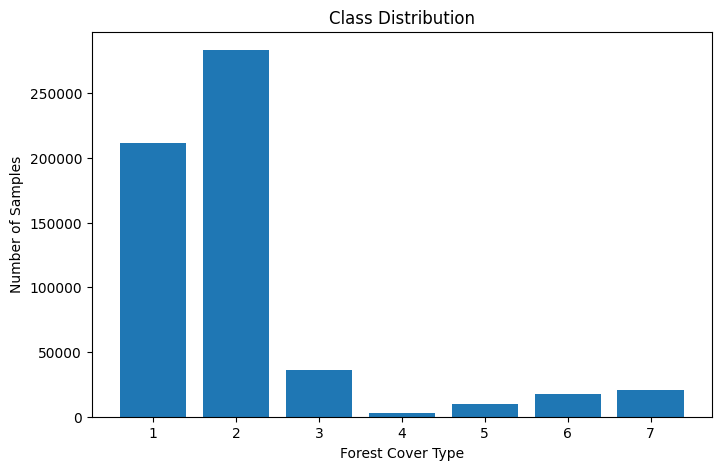

In [44]:
class_counts = pd.Series(y).value_counts().sort_index()

print("Class distribution:")
print(class_counts)

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.xticks(class_counts.index)
plt.show()

In [45]:
most_frequent = class_counts.max()
least_frequent = class_counts.min()

imbalance_ratio = most_frequent / least_frequent

print("Most frequent class:", most_frequent)
print("Least frequent class:", least_frequent)
print("Imbalance ratio:", imbalance_ratio)

Most frequent class: 283301
Least frequent class: 2747
Imbalance ratio: 103.13105205678923


In [46]:

y_zero = y - 1

num_classes = 7

y_one_hot = np.eye(num_classes)[y_zero]

print("Original classes:", np.unique(y))
print("Zero-indexed classes:", np.unique(y_zero))
print("One-hot encoded shape:", y_one_hot.shape)

print("\nFirst 5 one-hot encoded labels:")
print(y_one_hot[:5])

Original classes: [1 2 3 4 5 6 7]
Zero-indexed classes: [0 1 2 3 4 5 6]
One-hot encoded shape: (581012, 7)

First 5 one-hot encoded labels:
[[0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]]


In [47]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_zero,
    test_size=0.20,
    stratify=y_zero,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

Training set: (464809, 54)
Validation set: (58101, 54)
Testing set: (58102, 54)


In [48]:
y_train_oh = np.eye(num_classes)[y_train]
y_val_oh = np.eye(num_classes)[y_val]
y_test_oh = np.eye(num_classes)[y_test]

print("Training labels:", y_train_oh.shape)
print("Validation labels:", y_val_oh.shape)
print("Testing labels:", y_test_oh.shape)

Training labels: (464809, 7)
Validation labels: (58101, 7)
Testing labels: (58102, 7)


In [49]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Training feature mean:", np.mean(X_train))
print("Training feature standard deviation:", np.std(X_train))

Training feature mean: -2.406137286684203e-17
Training feature standard deviation: 0.9999999999999415


In [50]:
N = len(y_train)
K = num_classes

train_class_counts = np.bincount(y_train, minlength=K)

class_weights = N / (K * train_class_counts)

print("Training class counts:")
print(train_class_counts)

print("\nClass weights:")
for c in range(K):
    print(f"Class {c}: {class_weights[c]:.4f}")

Training class counts:
[169472 226640  28603   2198   7594  13894  16408]

Class weights:
Class 0: 0.3918
Class 1: 0.2930
Class 2: 2.3215
Class 3: 30.2099
Class 4: 8.7439
Class 5: 4.7791
Class 6: 4.0469


In [51]:
layer_sizes = [54, 64, 32, 16, 7]

print("DFNN Architecture:")
print(" -> ".join(map(str, layer_sizes)))

DFNN Architecture:
54 -> 64 -> 32 -> 16 -> 7


In [52]:
np.random.seed(42)

weights = {}
biases = {}

for i in range(len(layer_sizes) - 1):
    input_size = layer_sizes[i]
    output_size = layer_sizes[i + 1]

    # He initialization
    weights[i] = np.random.randn(input_size, output_size) * np.sqrt(2 / input_size)
    biases[i] = np.zeros((1, output_size))

print("Parameters initialized.")

for i in weights:
    print(
        f"Layer {i+1}: "
        f"W shape = {weights[i].shape}, "
        f"b shape = {biases[i].shape}"
    )

Parameters initialized.
Layer 1: W shape = (54, 64), b shape = (1, 64)
Layer 2: W shape = (64, 32), b shape = (1, 32)
Layer 3: W shape = (32, 16), b shape = (1, 16)
Layer 4: W shape = (16, 7), b shape = (1, 7)


In [53]:
def relu(z):
    return np.maximum(0, z)


def relu_derivative(z):
    return (z > 0).astype(float)


def softmax(z):
    # Numerical stability
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [54]:
def forward_propagation(X, weights, biases):
    activations = [X]
    z_values = []

    A = X


    for i in range(len(weights) - 1):
        Z = np.dot(A, weights[i]) + biases[i]
        A = relu(Z)

        z_values.append(Z)
        activations.append(A)


    last_layer = len(weights) - 1

    Z = np.dot(A, weights[last_layer]) + biases[last_layer]
    A = softmax(Z)

    z_values.append(Z)
    activations.append(A)

    return activations, z_values

In [55]:
def weighted_categorical_cross_entropy(y_true, y_pred, class_weights):
    epsilon = 1e-12

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    true_classes = np.argmax(y_true, axis=1)

    sample_weights = class_weights[true_classes]

    loss = -np.sum(
        sample_weights * np.sum(y_true * np.log(y_pred), axis=1)
    ) / len(y_true)

    return loss

In [56]:
def backward_propagation(
    X,
    y_true,
    activations,
    z_values,
    weights,
    biases,
    class_weights
):
    m = X.shape[0]

    gradients_W = {}
    gradients_b = {}


    y_pred = activations[-1]

    true_classes = np.argmax(y_true, axis=1)
    sample_weights = class_weights[true_classes].reshape(-1, 1)

    dZ = sample_weights * (y_pred - y_true) / m


    gradients_W[len(weights) - 1] = np.dot(
        activations[-2].T,
        dZ
    )

    gradients_b[len(weights) - 1] = np.sum(
        dZ,
        axis=0,
        keepdims=True
    )


    for i in range(len(weights) - 2, -1, -1):

        dA = np.dot(dZ, weights[i + 1].T)

        dZ = dA * relu_derivative(z_values[i])

        gradients_W[i] = np.dot(
            activations[i].T,
            dZ
        )

        gradients_b[i] = np.sum(
            dZ,
            axis=0,
            keepdims=True
        )

    return gradients_W, gradients_b

In [57]:
def predict(X, weights, biases):
    activations, _ = forward_propagation(X, weights, biases)

    probabilities = activations[-1]
    predictions = np.argmax(probabilities, axis=1)

    return predictions, probabilities

In [58]:
def calculate_accuracy(y_true, y_pred):
    true_labels = np.argmax(y_true, axis=1)

    return np.mean(true_labels == y_pred)

In [59]:
def train_model(
    X_train,
    y_train,
    X_val,
    y_val,
    weights,
    biases,
    class_weights,
    epochs=100,
    batch_size=128,
    learning_rate=0.01,
    patience=15
):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_loss = np.inf
    best_weights = None
    best_biases = None

    patience_counter = 0

    n_samples = X_train.shape[0]

    for epoch in range(epochs):


        permutation = np.random.permutation(n_samples)

        X_train_shuffled = X_train[permutation]
        y_train_shuffled = y_train[permutation]


        for start in range(0, n_samples, batch_size):

            end = start + batch_size

            X_batch = X_train_shuffled[start:end]
            y_batch = y_train_shuffled[start:end]


            activations, z_values = forward_propagation(
                X_batch,
                weights,
                biases
            )


            gradients_W, gradients_b = backward_propagation(
                X_batch,
                y_batch,
                activations,
                z_values,
                weights,
                biases,
                class_weights
            )


            for i in range(len(weights)):
                weights[i] -= learning_rate * gradients_W[i]
                biases[i] -= learning_rate * gradients_b[i]


        train_activations, _ = forward_propagation(
            X_train,
            weights,
            biases
        )

        train_probabilities = train_activations[-1]

        train_loss = weighted_categorical_cross_entropy(
            y_train,
            train_probabilities,
            class_weights
        )

        train_predictions = np.argmax(
            train_probabilities,
            axis=1
        )

        train_accuracy = calculate_accuracy(
            y_train,
            train_predictions
        )


        val_activations, _ = forward_propagation(
            X_val,
            weights,
            biases
        )

        val_probabilities = val_activations[-1]

        val_loss = weighted_categorical_cross_entropy(
            y_val,
            val_probabilities,
            class_weights
        )

        val_predictions = np.argmax(
            val_probabilities,
            axis=1
        )

        val_accuracy = calculate_accuracy(
            y_val,
            val_predictions
        )


        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_weights = {
                i: weights[i].copy()
                for i in weights
            }

            best_biases = {
                i: biases[i].copy()
                for i in biases
            }

            patience_counter = 0

        else:
            patience_counter += 1

        if patience_counter >= patience:

            print("\nEarly stopping triggered.")

            break


    if best_weights is not None:

        weights = best_weights
        biases = best_biases

    return weights, biases, history

In [60]:
test_predictions, test_probabilities = predict(
    X_test,
    weights,
    biases
)

print("Test probability shape:", test_probabilities.shape)
print("Test prediction shape:", test_predictions.shape)

print("\nFirst 20 predictions:")
print(test_predictions[:20])

print("\nFirst 20 actual classes:")
print(y_test[:20])

Test probability shape: (58102, 7)
Test prediction shape: (58102,)

First 20 predictions:
[1 6 0 6 0 3 3 2 6 2 2 2 2 2 2 0 6 3 3 6]

First 20 actual classes:
[0 1 1 1 5 1 1 1 1 0 1 3 1 0 0 2 0 1 1 1]


In [61]:
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 0.0889
Test Accuracy: 8.89%


In [62]:
precision = precision_score(
    y_test,
    test_predictions,
    average=None,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_predictions,
    average=None,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_predictions,
    average=None,
    zero_division=0
)

macro_precision = precision_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1-score:", macro_f1)

Macro Precision: 0.12430075248918603
Macro Recall: 0.176539329974122
Macro F1-score: 0.06563064854286013


In [63]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Class 1",
            "Class 2",
            "Class 3",
            "Class 4",
            "Class 5",
            "Class 6",
            "Class 7"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Class 1       0.47      0.11      0.17     21184
     Class 2       0.26      0.04      0.06     28331
     Class 3       0.08      0.28      0.12      3576
     Class 4       0.01      0.43      0.01       274
     Class 5       0.00      0.00      0.00       949
     Class 6       0.00      0.00      0.00      1737
     Class 7       0.05      0.38      0.09      2051

    accuracy                           0.09     58102
   macro avg       0.12      0.18      0.07     58102
weighted avg       0.31      0.09      0.10     58102



In [64]:
cm = confusion_matrix(y_test, test_predictions)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2251 1774 4214 5424   78 1208 6235]
 [2032 1019 6225 9207  281  959 8608]
 [ 178  522  994 1613    0    0  269]
 [  24   85   20  119    0    0   26]
 [  36  103  296  319    0   63  132]
 [  66  155  537  794    0    0  185]
 [ 177  217  163  478  117  117  782]]


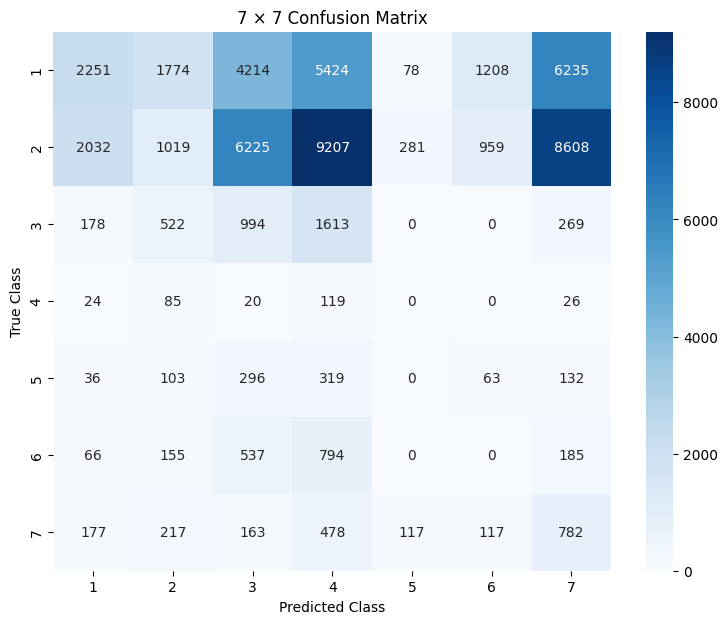

In [65]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(1, 8),
    yticklabels=range(1, 8)
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("7 × 7 Confusion Matrix")
plt.show()

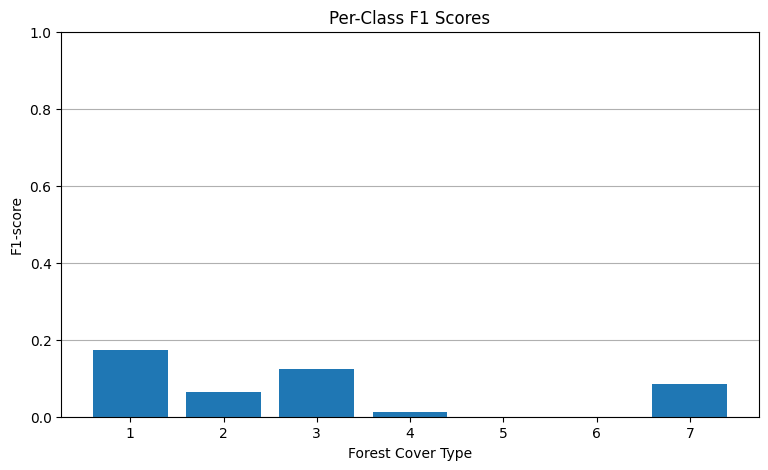

In [66]:
classes = np.arange(1, 8)

plt.figure(figsize=(9, 5))

plt.bar(classes, f1)

plt.xlabel("Forest Cover Type")
plt.ylabel("F1-score")
plt.title("Per-Class F1 Scores")
plt.xticks(classes)
plt.ylim(0, 1)
plt.grid(axis="y")

plt.show()

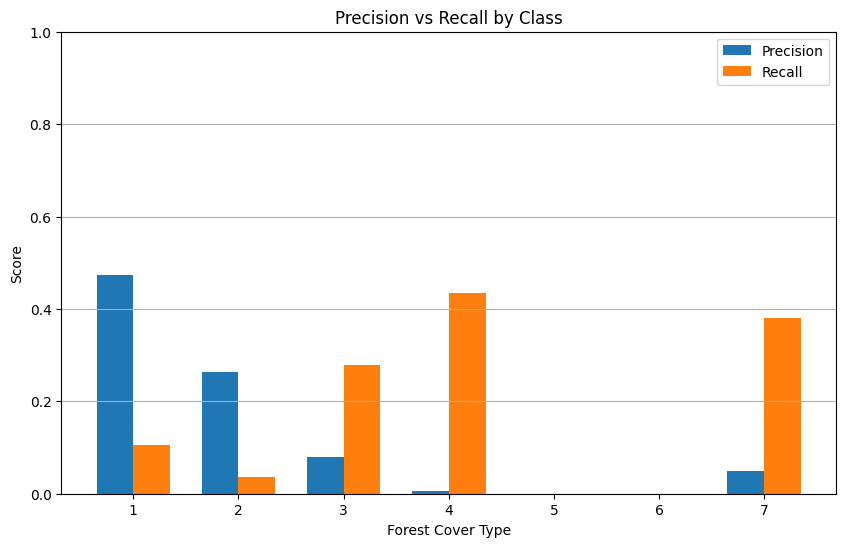

In [67]:
x = np.arange(1, 8)
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x + width / 2,
    recall,
    width,
    label="Recall"
)

plt.xlabel("Forest Cover Type")
plt.ylabel("Score")
plt.title("Precision vs Recall by Class")
plt.xticks(x)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y")

plt.show()

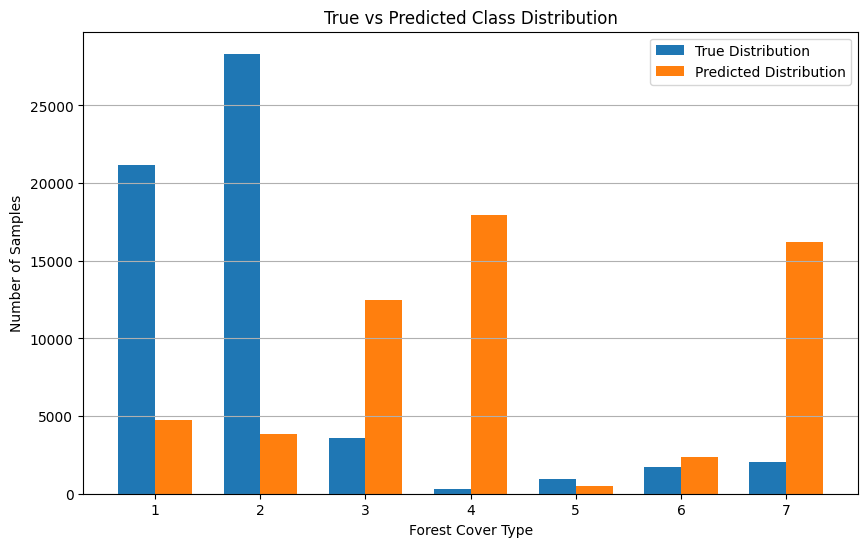

In [68]:
true_distribution = np.bincount(
    y_test,
    minlength=num_classes
)

predicted_distribution = np.bincount(
    test_predictions,
    minlength=num_classes
)

x = np.arange(1, 8)
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    true_distribution,
    width,
    label="True Distribution"
)

plt.bar(
    x + width / 2,
    predicted_distribution,
    width,
    label="Predicted Distribution"
)

plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distribution")
plt.xticks(x)
plt.legend()
plt.grid(axis="y")

plt.show()

In [69]:
print("FINAL MODEL EVALUATION")

print(f"Test Accuracy       : {test_accuracy:.4f}")
print(f"Macro Precision     : {macro_precision:.4f}")
print(f"Macro Recall        : {macro_recall:.4f}")
print(f"Macro F1-score      : {macro_f1:.4f}")

print("\nPer-Class F1 Scores:")
for i, score in enumerate(f1):
    print(f"Class {i + 1}: {score:.4f}")

FINAL MODEL EVALUATION
Test Accuracy       : 0.0889
Macro Precision     : 0.1243
Macro Recall        : 0.1765
Macro F1-score      : 0.0656

Per-Class F1 Scores:
Class 1: 0.1735
Class 2: 0.0633
Class 3: 0.1241
Class 4: 0.0131
Class 5: 0.0000
Class 6: 0.0000
Class 7: 0.0855
